## Boolean analysis demo and tests

Here we are trying to apply Boolean Fourier Analysis to the sign structure. The main reference is:

- Ryan O'Donnel. [Analysis of Boolean Functions](http://www.cs.cmu.edu/~odonnell/papers/Analysis-of-Boolean-Functions-by-Ryan-ODonnell.pdf).

Caveat: our space is not a space of boolean functions defined on $\{0,1\}^n$, as we are working in the sector of zero magnetization (equal number of spins up and down). So, the set of parity functions that is used as a basis in BFA is *not* an orthonormal basis of the space of boolean functions defined in the sector of zero magnetization.

Possible workarounds:

- It is possible to consider the full eigenstate $\{0, 1\}^n \to \mathbb R$, not only the sign structure. Products are still form the orthonormal basis in this space.
- It is possible to consider the sign structure with zeroes: $\{0, 1\}^n \to \{-1, 0, 1\}$.
- Populate the space outside of the sector of zero magnetization with +1/-1 randomly instead of 0's.

In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

In [2]:
from pathlib import Path

FOURIER_BASIS_DIR = Path("fourier-bases")
FOURIER_BASIS_DIR.mkdir(exist_ok=True)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
from ipywidgets import interact, interact_manual, IntSlider, FloatSlider

from heisenberg_hamiltonians import HeisenbergJ1J2

from spin_lattices import (
    ChainLattice,
    SquareLattice,
    KagomeLattice,
)

from scipy.stats import entropy
from boolean_analysis import (
    get_fourier_transform_matrix,
    calculate_fourier_transform_matrix,
    BooleanFourierAnalyser,
    SignalOption,
)

%matplotlib inline

In [4]:
fourier_transform_matrix_cache = {}

In [5]:
analyzer_sym = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        SquareLattice(width=4, height=4),
        J1=1,
        J2=0,
        use_symmetries=True,
        spin_inversion=1,
    ),
    use_symmetries=True,
    fourier_transform_matrix_cache=fourier_transform_matrix_cache,
)

number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Fourier transform matrix not found, we have to calculate it. This can take some time, you can get a coffee.


100%|██████████| 16/16 [00:01<00:00, 14.52it/s]


Saving basis to file fourier-bases/fourier_transform_matrix-e2331588b59edde2054e2712731baf69.feather
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
Ground state energy is -44.9139328337


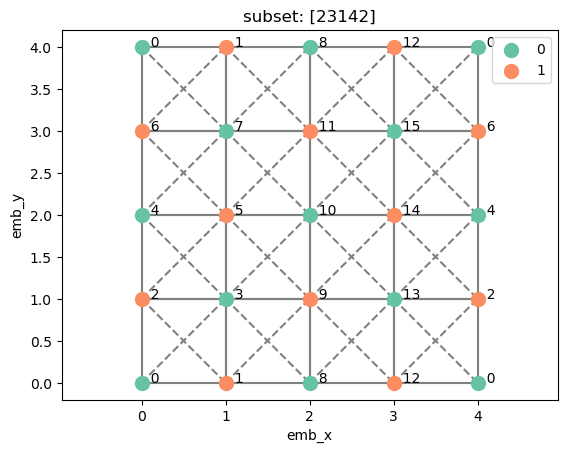

In [6]:
analyzer_sym.visualize_spectre_support_lattice()

Okay, that's the Marshall's sign rule. Seems to be working. Let's look on the rest of the terms.

<AxesSubplot: >

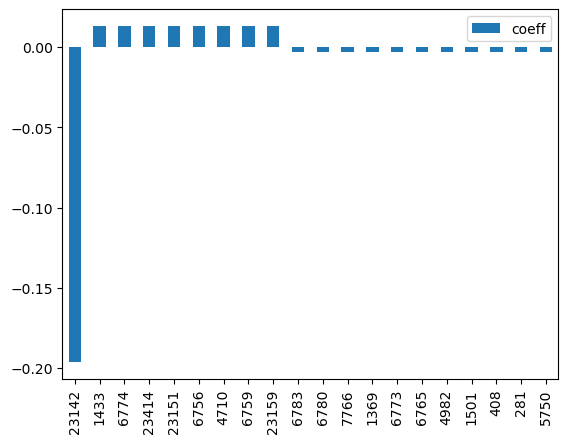

In [7]:
analyzer_sym.visualize_spectre_support_barplot()

Looks like we have a lot of non-zero terms!

In [8]:
signal = SignalOption("sign", 0)
nonzero_terms = (analyzer_sym.get_spectre_df(signal)["coeff"] != 0).sum()
zero_terms = (analyzer_sym.get_spectre_df(signal)["coeff"] == 0).sum()
print(f"{nonzero_terms=}, {zero_terms=}")

nonzero_terms=433, zero_terms=372


What happens if we remove all terms but the first one?

In [9]:
correct_signs = np.sign(
    analyzer_sym.system.get_df_ground_state(canonical_basis=True)[
        "eigenstate_coeff"
    ]
).values
assert (analyzer_sym.predict(signal) == correct_signs).all()
assert (
    np.sign(analyzer_sym.predict(signal, keep_first=1)) == correct_signs
).all()

Fourier transform matrix not found, we have to calculate it. This can take some time, you can get a coffee.


100%|██████████| 16/16 [08:49<00:00, 33.10s/it]


Saving basis to file fourier-bases/fourier_transform_matrix-ec0e2b6165942a62e0f5093700a91547.feather


We still have 100% accuracy! That's because those nonzero terms are coming from the fact we are working in zero-magnetization sector.

In [10]:
run_long_test = False
if run_long_test:

    pred = analyzer_sym.predict(
        signal,
        keep_first=nonzero_terms - 1,
    )
    assert (np.abs(pred - correct_signs) < 0.1).all()

Let's check that symmetries work correctly

In [11]:
analyzer_nosym = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        SquareLattice(width=4, height=4),
        J1=1,
        J2=0,
        use_symmetries=True,
        spin_inversion=1,
    ),
    use_symmetries=False,
    fourier_transform_matrix_cache=fourier_transform_matrix_cache,
)

number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Found cached fourier basis, will use it
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
Ground state energy is -44.9139328337


In [12]:
assert (analyzer_sym.predict(signal) == analyzer_nosym.predict(signal)).all

In [13]:
analyzer = analyzer_sym

In [14]:
analyzer.spectre_entropy(signal)

5.102812028151233

In [15]:
analyzer.spectre_entropy(SignalOption("value", 0))

4.101916547701195

Entropy seems to be wrong measure of "spreadness" of the function over the basis.

<AxesSubplot: >

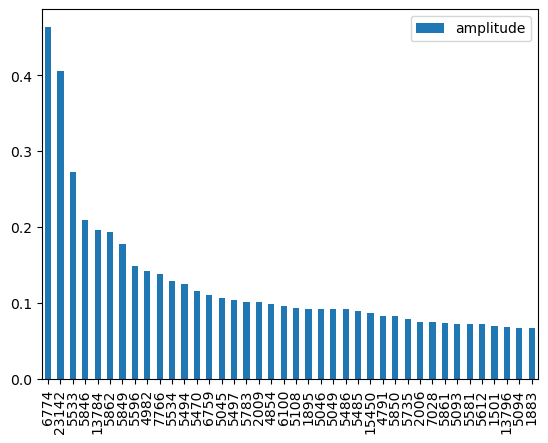

In [16]:
analyzer.system.get_df_ground_state().sort_values(
    "amplitude", ascending=False
).iloc[:40].plot.bar(y="amplitude")

<AxesSubplot: >

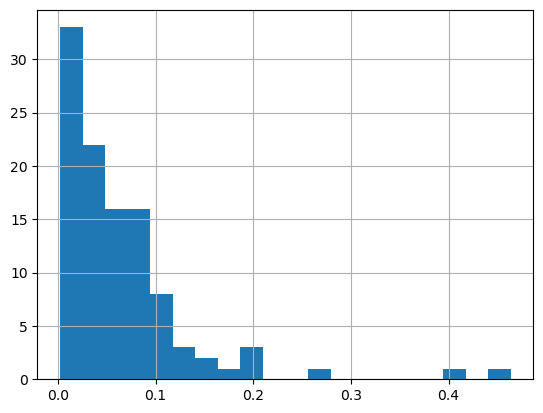

In [17]:
analyzer.system.get_df_ground_state()["amplitude"].hist(bins=20)

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
analyzer_cache = {}


@interact_manual(
    J2=FloatSlider(
        min=0.0,
        max=1.0,
        value=0,
        step=0.01,
    ),
    signal_kind=["sign", "value"],
    eigenstate=IntSlider(min=0, max=9, value=0),
    n_support_lattice=(0, 10),
    keep_first=IntSlider(min=-1, max=9, value=-1),
)
def analyze_system(J2, signal_kind, eigenstate, n_support_lattice, keep_first):
    if keep_first == -1:
        keep_first = None

    signal = SignalOption(signal_kind, eigenstate)

    if (analyzer := analyzer_cache.get((J2, eigenstate))) is None:
        analyzer = BooleanFourierAnalyser(
            system=HeisenbergJ1J2(
                KagomeLattice(width=2, height=2),
                J1=1,
                J2=J2,
                use_symmetries=True,
                spin_inversion=1,
            ),
            fourier_transform_matrix_cache=fourier_transform_matrix_cache,
            use_symmetries=True,
            eigenstates=eigenstate + 1,
        )
        analyzer_cache[J2, eigenstate] = analyzer
    fig, ax = plt.subplots()

    analyzer.visualize_spectre_support_barplot(signal, abs=False, ax=ax)
    ax.set_title(f"J2={J2}, signal={signal}")

    #     fig, ax = plt.subplots()
    #     analyzer.visualize_spectre_values_hist(signal, ax=ax)

    if keep_first:
        unweighted_accuracy = analyzer.sign_prediction_accuracy(
            eigenstate=eigenstate, keep_first=keep_first, weighted=False
        )
        weighted_accuracy = analyzer.sign_prediction_accuracy(
            eigenstate=eigenstate, keep_first=keep_first, weighted=True
        )
        print(
            f"Sign prediction accuracy ({keep_first} terms kept): "
            f"unweighted: {unweighted_accuracy}, weighted (overlap): {weighted_accuracy}",
        )
    fig, axes = plt.subplots(
        ncols=n_support_lattice, figsize=(n_support_lattice * 5, 5)
    )
    for m, ax in enumerate(axes):
        analyzer.visualize_spectre_support_lattice(signal=signal, m=m, ax=ax)

interactive(children=(FloatSlider(value=0.0, description='J2', max=1.0, step=0.01), Dropdown(description='sign…

## TODO

- [✓] Factor Fourier components by group action
- Why sign of both components is negative?
    - Can be both positive or negative. Equal because of the symmetry.
- Use predictions of the largest components instead of zeroes outside of {M=0}
    - Did it differently: keep only several largest components (but probably we can return here)
- Whether NN better learnt with small amount of XOR's?
- Upscale XOR's for larger sizes?
- Overlap vs. accuracy.
- When calculating Fourier transform, sample w.r.t. probability distribution given by the amplitude of the ground state.